In [ ]:
pip install audiomentations

In [2]:
import numpy as np
import pandas as pd
import librosa
import random
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import librosa.display
from pathlib import Path
import random
from typing import List, Tuple, Dict, Optional, Union
import warnings
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras
from keras import layers, ops, backend
import jax
import jax.numpy as jnp
from audiomentations import (
    Compose, 
    AddGaussianNoise, 
    TimeStretch, 
    PitchShift, 
    Shift,
    Gain,
    TimeMask,
    PolarityInversion
)
from sklearn.model_selection import train_test_split
import seaborn as sns

In [3]:
sr = 22050

In [4]:
path = "/kaggle/input/urbansound8k/"
df = pd.read_csv("/kaggle/input/urbansound8k/UrbanSound8K.csv")
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [5]:
df.groupby("classID").sample(1)

,slice_file_name,fsID,start,end,salience,fold,classID,class
6001,30204-0-0-12.wav,30204,6.286916,10.286916,1,3,0,air_conditioner
8725,99812-1-0-2.wav,99812,39.176254,43.176254,2,7,1,car_horn
8258,84143-2-0-12.wav,84143,6.000000,10.000000,2,7,2,children_playing
5533,209672-3-0-0.wav,209672,0.735508,2.259060,1,10,3,dog_bark
6517,46669-4-0-10.wav,46669,5.000000,9.000000,1,1,4,drilling
4570,18592-5-0-3.wav,18592,8.004182,12.004182,1,9,5,engine_idling
2057,148837-6-2-0.wav,148837,2.959783,4.424286,1,4,6,gun_shot
7120,62837-7-0-37.wav,62837,18.500000,22.500000,1,3,7,jackhammer
2722,159750-8-0-0.wav,159750,0.749887,4.749887,1,2,8,siren
8669,99179-9-0-12.wav,99179,6.000000,10.000000,1,8,9,street_music


In [40]:
for i in range(0,10):
    if i == 1 or i == 6:
        print(i, len(df[df["classID"]==i]))
    else:
        print(i, len(df[df["classID"]==i]))

0 1000
1 429
2 1000
3 1000
4 1000
5 1000
6 374
7 1000
8 929
9 1000


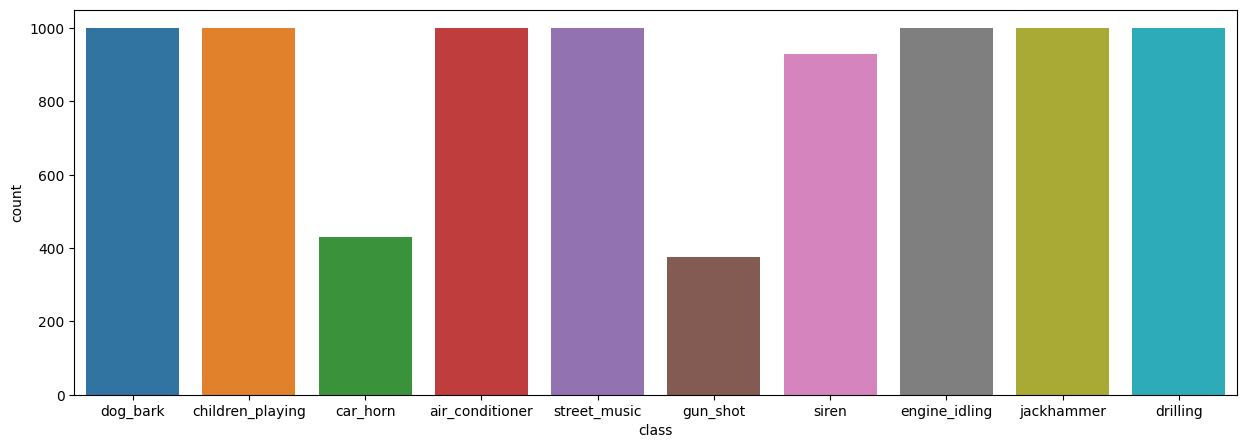

In [7]:
fig = plt.figure(figsize=(15,5))
sns.countplot(data = df,x='class')
plt.show()

In [ ]:
class AudioAugmenter:
    
    def __init__(self, sr: int = 22050, n_mels: int = 128, n_fft: int = 2048, 
                 hop_length: int = 512, fmin: int = 20, fmax: int = 8000,
                 time_steps: int = 128):

        self.sr = sr
        self.mel_params = {
            "n_mels": n_mels,
            "n_fft": n_fft,
            "hop_length": hop_length,
            "fmin": fmin,
            "fmax": fmax,
        }
        self.time_steps = time_steps
        
        # Create the augmentation pipeline
        self.augmentation1 = Compose([
            AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=1)
        ])
        self.augmentation2 = Compose([
            TimeStretch(min_rate=0.8, max_rate=1.25, p=1.0)
        ])
        self.augmentation3 = Compose([
            PitchShift(min_semitones=-4, max_semitones=4, p=1.0)
        ])
        self.augmentation4 = Compose([
            Shift(min_shift=-0.4, max_shift=0.4, p=1.0)
        ])
        self.augmentation5 = Compose([
            Gain(min_gain_db=-6, max_gain_db=6, p=1.0)
        ])
        self.augmentation6 = Compose([
            TimeMask(min_band_part=0.1, max_band_part=0.15, fade=True, p=1.0)
        ])

        
    def load_audio(self, file_path: str) -> np.ndarray:

        y, _ = librosa.load(file_path, sr=self.sr)
        return y
    
    def augment_audio(self, audio: np.ndarray) -> np.ndarray:

        augmented_audio1 = self.augmentation1(
            samples=audio, 
            sample_rate=self.sr
        )
        augmented_audio2 = self.augmentation2(
            samples=audio, 
            sample_rate=self.sr
        )
        augmented_audio3 = self.augmentation3(
            samples=audio, 
            sample_rate=self.sr
        )
        augmented_audio4 = self.augmentation4(
            samples=audio, 
            sample_rate=self.sr
        )
        augmented_audio5 = self.augmentation5(
            samples=audio, 
            sample_rate=self.sr
        )
        augmented_audio6 = self.augmentation6(
            samples=audio, 
            sample_rate=self.sr
        )

        return augmented_audio1,augmented_audio2,augmented_audio3,augmented_audio4,augmented_audio5,augmented_audio6
    
    def create_mel_spectrogram(self, audio: np.ndarray) -> np.ndarray:

        mel_spec = librosa.feature.melspectrogram(
            y=audio, sr=self.sr, **self.mel_params
        )
        
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        mel_spec_normalized = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
        
        if mel_spec_normalized.shape[1] != self.time_steps:
            from skimage.transform import resize
            mel_spec_normalized = resize(
                mel_spec_normalized, 
                (self.mel_params["n_mels"], self.time_steps), 
                mode='constant', 
                anti_aliasing=True
            )
        
        mel_spec_reshaped = np.transpose(mel_spec_normalized).reshape(
            self.time_steps, self.mel_params["n_mels"], 1
        )
        
        return mel_spec_reshaped
    
    def process_file(self, file_path: str) -> Tuple[np.ndarray, np.ndarray]:

        audio = self.load_audio(file_path)
        
        augmented_audio1,augmented_audio2,augmented_audio3,augmented_audio4,augmented_audio5,augmented_audio6 = self.augment_audio(audio)
        
        original_spec = self.create_mel_spectrogram(audio)
        augmented_spec1 = self.create_mel_spectrogram(augmented_audio1)
        augmented_spec2 = self.create_mel_spectrogram(augmented_audio2)
        augmented_spec3 = self.create_mel_spectrogram(augmented_audio3)
        augmented_spec4 = self.create_mel_spectrogram(augmented_audio4)
        augmented_spec5 = self.create_mel_spectrogram(augmented_audio5)
        augmented_spec6 = self.create_mel_spectrogram(augmented_audio6)
        
        return original_spec, augmented_spec1, augmented_spec2, augmented_spec3, augmented_spec4, augmented_spec5, augmented_spec6

In [9]:
augmenter = AudioAugmenter(
    sr=22050,
    n_mels=128,
    n_fft=2048,
    hop_length=512,
    fmin=20,
    fmax=8000,
    time_steps=128
)

In [10]:
file_list = []

f = 1
t_list = df.index.tolist()
for x in t_list:
    file_list.append(x)


In [11]:
audio_files = []
labels = []

In [12]:
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [13]:
for x in file_list:
    audio_path = path + "/" + "fold" + str(df.iloc[x]["fold"]) + "/" + df.iloc[x]['slice_file_name']
    audio_files.append(audio_path)
    labels.append(int(df.iloc[x]['classID']))

In [14]:
len(audio_files),len(labels)

(8732, 8732)

In [15]:
X = []
Y = []
X_train = []
Y_train = []
X_test = []
Y_test = []

In [ ]:
for x,y in tqdm(zip(audio_files,labels)):
    specs = augmenter.process_file(x)
    if y == 1 or y == 6:
        for spec in specs:
            X.append(spec)
            Y.append(y)
    else:
        for spec in specs[:3]:
            X.append(spec)
            Y.append(y)

In [40]:
X = np.array(X)
Y = np.array(Y)

In [41]:
X.shape,Y.shape

((29408, 128, 128, 1), (29408,))

In [42]:
np.save('./us8k_trainX',X)
np.save('./us8k_trainY',Y)

In [17]:
X = np.load("/kaggle/working/us8k_trainX.npy")
Y = np.load("/kaggle/working/us8k_trainY.npy")

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.05, random_state=42)

In [19]:
X.shape,Y.shape,X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((29408, 128, 128, 1),
 (29408,),
 (27937, 128, 128, 1),
 (27937,),
 (1471, 128, 128, 1),
 (1471,))

(<matplotlib.image.AxesImage at 0x797518802140>, 7)

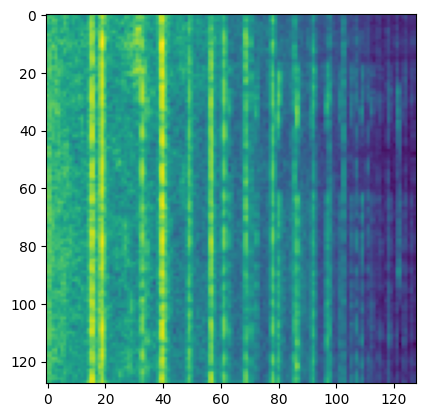

In [20]:
plt.imshow(X_train[10]),Y_train[0]

In [ ]:
input_shape=(128, 128, 1)
num_classes=10
head_size=64
num_heads=4
ff_dim=128
num_transformer_blocks=2
mlp_units=[256,128]
dropout=0.4
"""
CNN frontend extracts local spectral features before tokenization.
Each time step is still treated as a token, but with enriched features.
"""
time_steps, num_mel_bands, channels = input_shape
projection_dim = head_size * num_heads

inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

x = layers.MaxPooling2D((1, 2))(x)

x = layers.Conv2D(128, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

x = layers.MaxPooling2D((1, 2))(x)

new_mel_bands = num_mel_bands // 4 
reshaped = layers.Reshape((time_steps, new_mel_bands * 128))(x)

encoded_patches = layers.Dense(projection_dim)(reshaped)

positions = ops.arange(0, time_steps)
position_embedding = layers.Embedding(input_dim=time_steps, output_dim=projection_dim)(positions)
encoded_patches = encoded_patches + position_embedding

for _ in range(num_transformer_blocks):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])
    
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x4 = layers.Dense(ff_dim, activation=None)(x3)
    x4 = layers.LeakyReLU(negative_slope=0.1)(x4)
    x4 = layers.Dropout(dropout)(x4)
    x4 = layers.Dense(projection_dim)(x4)
    x4 = layers.Dropout(dropout)(x4)
    encoded_patches = layers.Add()([x4, x2])

representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)

for units in mlp_units:
    representation = layers.Dense(units)(representation)
    representation = layers.LeakyReLU(negative_slope=0.1)(representation)
    representation = layers.Dropout(dropout)(representation)

outputs = layers.Dense(num_classes, activation="softmax")(representation)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 32)   │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 32)   │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 128, 128, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         18,496 │ leaky_re_lu[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 64, 64)    │              0 │ leaky_re_lu_1[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 64, 128)   │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 64, 128)   │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 128, 64, 128)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 128, 32, 128)   │              0 │ leaky_re_lu_2[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 128, 4096)      │              0 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128, 256)       │      1,048,832 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 128, 256)       │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 128, 256)       │            512 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention 

 Total params: 1,903,114 (7.26 MB)

 Trainable params: 1,902,666 (7.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=1e-4,
    weight_decay=1e-5
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
model.fit(x=X_train, y=Y_train, epochs=20, batch_size=64, validation_split=0.05)

Epoch 1/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 66s 124ms/step - accuracy: 0.4129 - loss: 1.6671 - val_accuracy: 0.1396 - val_loss: 5.7800
Epoch 2/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 37s 77ms/step - accuracy: 0.7720 - loss: 0.7097 - val_accuracy: 0.8597 - val_loss: 0.4863
Epoch 3/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.8482 - loss: 0.4718 - val_accuracy: 0.9005 - val_loss: 0.3363
Epoch 4/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.8967 - loss: 0.3311 - val_accuracy: 0.9184 - val_loss: 0.2905
Epoch 5/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.9233 - loss: 0.2450 - val_accuracy: 0.9170 - val_loss: 0.3177
Epoch 6/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.9347 - loss: 0.2018 - val_accuracy: 0.9492 - val_loss: 0.2196
Epoch 7/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.9547 - loss: 0.1410 - val_accuracy: 0.9549 - val_loss: 0.1849
Epoch 8/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.9671 - loss: 0.1048 -

In [24]:
model.evaluate(X_test,Y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9734 - loss: 0.0841


[0.08264956623315811, 0.9755268692970276]

In [25]:
model.save('us8k_train.keras')

In [26]:
model2 = keras.saving.load_model("us8k_train.keras")

In [27]:
model2.evaluate(X_test,Y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9734 - loss: 0.0841


[0.08264956623315811, 0.9755268692970276]

## ESC50 train

In [42]:
path = "/kaggle/input/environmental-sound-classification-50/audio/audio/"
df = pd.read_csv("/kaggle/input/environmental-sound-classification-50/esc50.csv")
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


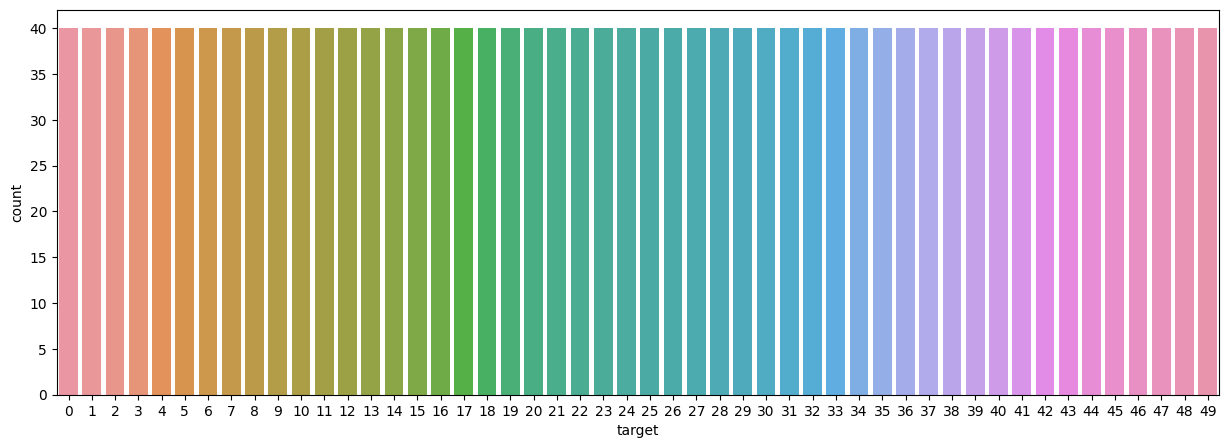

In [43]:
fig = plt.figure(figsize=(15,5))
sns.countplot(data = df,x='target')
plt.show()

In [21]:
file_list = []

f = 1
t_list = df.index.tolist()
for x in t_list:
    file_list.append(x)

audio_files = []
labels = []


In [22]:
for x in file_list:
    audio_path = path + df.iloc[x]['filename']
    audio_files.append(audio_path)
    labels.append(int(df.iloc[x]['target']))

In [23]:
len(audio_files),len(labels)

(2000, 2000)

In [24]:
augmenter = AudioAugmenter(
    sr=22050,
    n_mels=128,
    n_fft=2048,
    hop_length=512,
    fmin=20,
    fmax=8000,
    time_steps=128
)

In [28]:
X = []
Y = []
X_train = []
Y_train = []
X_test = []
Y_test = []

In [26]:
for x,y in tqdm(zip(audio_files,labels)):
    specs = augmenter.process_file(x)
    for spec in specs:
        X.append(spec)
        Y.append(y)

2000it [09:31,  3.50it/s]


In [27]:
X = np.array(X)
Y = np.array(Y)

In [28]:
np.save('./esc50_trainX',X)
np.save('./esc50_trainY',Y)

In [29]:
X = np.load("/kaggle/working/esc50_trainX.npy")
Y = np.load("/kaggle/working/esc50_trainY.npy")

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.05, random_state=42)

In [31]:
X.shape,Y.shape,X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((14000, 128, 128, 1),
 (14000,),
 (13300, 128, 128, 1),
 (13300,),
 (700, 128, 128, 1),
 (700,))

(<matplotlib.image.AxesImage at 0x796fe5b56bc0>, 39)

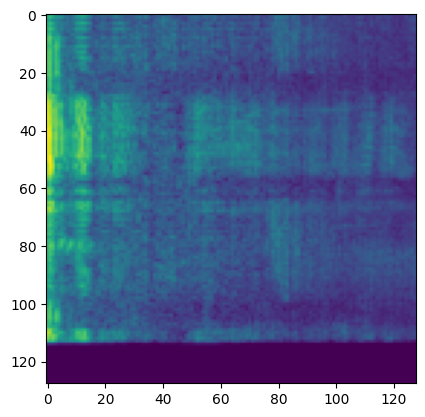

In [32]:
plt.imshow(X_train[1]),Y_train[0]

In [ ]:
input_shape=(128, 128, 1)
num_classes=50
head_size=64
num_heads=4
ff_dim=128
num_transformer_blocks=2
mlp_units=[256,128]
dropout=0.4
time_steps, num_mel_bands, channels = input_shape
projection_dim = head_size * num_heads

inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

x = layers.MaxPooling2D((1, 2))(x)

x = layers.Conv2D(128, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

x = layers.MaxPooling2D((1, 2))(x)

new_mel_bands = num_mel_bands // 4  
reshaped = layers.Reshape((time_steps, new_mel_bands * 128))(x)

encoded_patches = layers.Dense(projection_dim)(reshaped)

positions = ops.arange(0, time_steps)
position_embedding = layers.Embedding(input_dim=time_steps, output_dim=projection_dim)(positions)
encoded_patches = encoded_patches + position_embedding

for _ in range(num_transformer_blocks):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])
    
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x4 = layers.Dense(ff_dim, activation=None)(x3)
    x4 = layers.LeakyReLU(negative_slope=0.1)(x4)
    x4 = layers.Dropout(dropout)(x4)
    x4 = layers.Dense(projection_dim)(x4)
    x4 = layers.Dropout(dropout)(x4)
    encoded_patches = layers.Add()([x4, x2])

representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)

for units in mlp_units:
    representation = layers.Dense(units)(representation)
    representation = layers.LeakyReLU(negative_slope=0.1)(representation)
    representation = layers.Dropout(dropout)(representation)

outputs = layers.Dense(num_classes, activation="softmax")(representation)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 32)   │            320 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 32)   │            128 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_7 (LeakyReLU) │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 64)   │         18,496 │ leaky_re_lu_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 128, 128, 64)   │            256 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_8 (LeakyReLU) │ (None, 128, 128, 64)   │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 128, 64, 64)    │              0 │ leaky_re_lu_8[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 128, 64, 128)   │         73,856 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 128, 64, 128)   │            512 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_9 (LeakyReLU) │ (None, 128, 64, 128)   │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 128, 32, 128)   │              0 │ leaky_re_lu_9[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 128, 4096)      │              0 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 128, 256)       │      1,048,832 │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 128, 256)       │              0 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_5     │ (None, 128, 256)       │            512 │ add_5[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 1,908,274 (7.28 MB)

 Trainable params: 1,907,826 (7.28 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=1e-4,
    weight_decay=1e-5
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
model.fit(x=X_train, y=Y_train, epochs=40, batch_size=16, validation_split=0.2)

Epoch 1/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.0755 - loss: 3.7100 - val_accuracy: 0.3248 - val_loss: 2.5554
Epoch 2/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.2586 - loss: 2.7045 - val_accuracy: 0.5553 - val_loss: 1.7046
Epoch 3/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.4248 - loss: 1.9965 - val_accuracy: 0.6654 - val_loss: 1.2277
Epoch 4/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.5476 - loss: 1.5439 - val_accuracy: 0.7380 - val_loss: 0.8893
Epoch 5/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6336 - loss: 1.2324 - val_accuracy: 0.8244 - val_loss: 0.6395
Epoch 6/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.6946 - loss: 1.0147 - val_accuracy: 0.8568 - val_loss: 0.5109
Epoch 7/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7610 - loss: 0.8261 - val_accuracy: 0.8850 - val_loss: 0.4244
Epoch 8/40
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7967 - loss: 0.6769 - 

In [36]:
model.evaluate(X_test,Y_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9692 - loss: 0.1726


[0.16180139780044556, 0.9699999690055847]

In [37]:
model.save('esc50_train.keras')

In [38]:
model2 = keras.saving.load_model(filepath='/kaggle/working/esc50_train.keras')

In [39]:
model2.evaluate(X_test,Y_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9692 - loss: 0.1726


[0.16180139780044556, 0.9699999690055847]